# 01. job tag 探索

job tag（日本版O-NET）のダウンロードデータを読み込み、構造を確認する。

- `IPD_DL_description_7_01.csv` — 職業名・分類などの文字列情報
- `IPD_DL_numeric_7_00.csv` — 職業興味・仕事価値観・スキル・知識・アビリティなどの数値情報


## 読み込み

どちらのCSVも、先頭に注記行が入っており、実際のヘッダーは日本語ラベル行・IPDコード行の2段構成になっている。
CP932（Shift-JIS）エンコーディング。


In [1]:
import re
import pandas as pd
from ipd_loader import load_description, load_numeric

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

desc, desc_labels = load_description()
num, num_labels = load_numeric()

print("description:", desc.shape)
print("numeric:", num.shape)

description: (556, 102)
numeric: (518, 479)


## 職業数

In [2]:
id_col = num.columns[0]  # 収録番号
name_col = num.columns[1]  # 職業名

print("description の職業数（収録番号ユニーク）:", desc.iloc[:, 0].nunique())
print("numeric の職業数（収録番号ユニーク、数値データを持つ職業のみ）:", num[id_col].nunique())

# 収録番号の欠番（掲載終了などで欠番になっている）
nums = pd.to_numeric(desc.iloc[:, 0], errors="coerce").dropna().astype(int)
full_range = set(range(nums.min(), nums.max() + 1))
missing = sorted(full_range - set(nums))
print(f"収録番号の範囲: {nums.min()}–{nums.max()}（欠番 {len(missing)} 件）")


description の職業数（収録番号ユニーク）: 556
numeric の職業数（収録番号ユニーク、数値データを持つ職業のみ）: 518
収録番号の範囲: 1–584（欠番 28 件）


## 数値データの列構成

`IPD_XX_YY_...` のコード体系で領域が分かれている。YYごとに何項目あるか、代表ラベルとともに確認する。


In [3]:
rows = []
for code, label in num_labels.items():
    m = re.match(r"IPD_(\d+)_(\d+)_", str(code))
    if not m:
        continue
    rows.append({"group": f"{m.group(1)}_{m.group(2)}", "code": code, "label": label})

group_df = pd.DataFrame(rows)
summary = (
    group_df.groupby("group")
    .agg(n=("code", "size"), 例=("label", "first"))
    .sort_index()
)
summary


,n,例
group,,
01_01,1,収録番号
02_01,1,職業名
04_01,6,現実的
04_02,11,達成感
04_03,78,読解力
04_04,66,ビジネスと経営
04_05,39,他者とのかかわり
04_06,9,高卒未満
04_07,10,特に必要ない


領域の対応（ラベルから判読）:

| group | 内容 |
|---|---|
| 04_01 | 職業興味（RIASEC 6因子） |
| 04_02 | 仕事価値観（11項目） |
| 04_03 | スキル（78項目） |
| 04_04 | 知識（66項目） |
| 04_05 | ジェネリックスキル（39項目） |
| 04_06〜04_09 | 必要な学歴・訓練・経験（カテゴリ分布） |
| 04_10, 04_12 | アビリティ（41 + 35項目） |
| 04_11 | 雇用形態分布 |
| 05_00〜05_37 | タスク（最大37個、内容文＋実施率など） |
| 77_04, 88_xx | メタ情報（情報源・更新年度） |
| 99_01 | サンプルサイズ不足フラグ（データ品質） |

推薦の特徴ベクトルにはまず 04_01（職業興味）・04_02（仕事価値観）・04_10/04_12（アビリティ）あたりが候補になりそう。


## RIASEC（職業興味）の分布を見る

/var/folders/78/wv3zy0h162xbn9ls8tsq1x7c0000gn/T/ipykernel_5586/1919714225.py:8: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/78/wv3zy0h162xbn9ls8tsq1x7c0000gn/T/ipykernel_5586/1919714225.py:8: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/78/wv3zy0h162xbn9ls8tsq1x7c0000gn/T/ipykernel_5586/1919714225.py:8: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/78/wv3zy0h162xbn9ls8tsq1x7c0000gn/T/ipykernel_5586/1919714225.py:8: UserWarning: Glyph 30740 (\N{CJK UNIFIED IDEOGRAPH-7814}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/78/wv3zy0h162xbn9ls8tsq1x7c0000gn/T/ipykernel_5586/1919714225.py:8: UserWarning: Glyph 31350 (\N{CJK UNIFIED IDEOGRAPH-7A76}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/78/wv3zy0h162xbn9

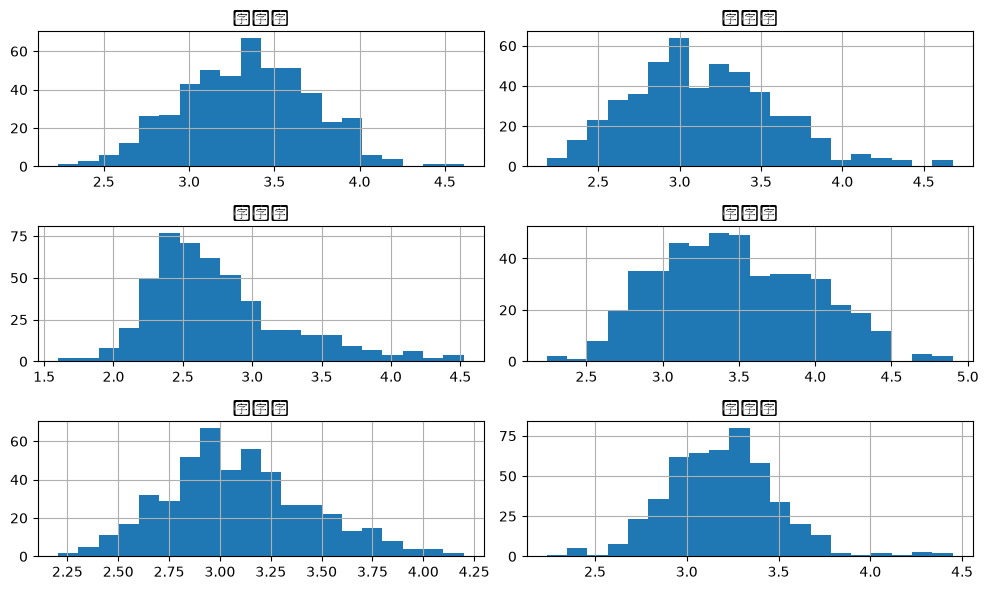

,現実的,研究的,芸術的,社会的,企業的,慣習的
count,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000
mean,3.336413,3.150017,2.754293,3.474969,3.092741,3.191975
std,0.378395,0.441832,0.503516,0.491757,0.360833,0.304581
min,2.232000,2.185000,1.600000,2.241000,2.204000,2.238000
25%,3.070250,2.834500,2.403250,3.117000,2.854750,2.985250
50%,3.339500,3.109000,2.647500,3.431500,3.056500,3.193500
75%,3.590000,3.428250,3.000000,3.851750,3.310750,3.368000
max,4.610000,4.677000,4.524000,4.900000,4.198000,4.448000


In [4]:
import matplotlib.pyplot as plt

riasec_cols = [c for c in num.columns if re.match(r"IPD_04_01_", str(c))]
riasec = num[riasec_cols].apply(pd.to_numeric, errors="coerce")
riasec.columns = [num_labels[c] for c in riasec_cols]

riasec.hist(figsize=(10, 6), bins=20)
plt.tight_layout()
plt.show()

riasec.describe()


## 欠損状況（仕事価値観・アビリティ）

In [5]:
value_cols = [c for c in num.columns if re.match(r"IPD_04_02_", str(c))]
ability_cols = [c for c in num.columns if re.match(r"IPD_04_10_|IPD_04_12_", str(c))]

for name, cols in [("仕事価値観", value_cols), ("アビリティ", ability_cols)]:
    sub = num[cols].apply(pd.to_numeric, errors="coerce")
    missing_rate = sub.isna().mean().mean()
    print(f"{name}: {len(cols)}項目, 平均欠損率 {missing_rate:.1%}")


仕事価値観: 11項目, 平均欠損率 14.1%
アビリティ: 76項目, 平均欠損率 13.5%


## 次のステップ

- 職業興味・仕事価値観・アビリティを合わせた特徴ベクトルを作り、次元削減（UMAP/PCA）で分布を見る
- 職業の「知名度」推定方法を検討する（公開データがないため代理指標が必要）
- 語彙変換表（docs/vocab.md）の項目を、この数値データの列（04_01〜04_12）に対応づけて埋めていく
